# Bước 3 — Forecast model: SARIMAX per `(hotel, room_type)`

**Mục tiêu**: train 5 SARIMAX model (1 per room_type) dự báo giá phòng theo `stay_date`, evaluate trên 30 ngày holdout cuối series.

**⚠️ Methodology note — lệch ROADMAP**:

ROADMAP §3 Bước 3 dùng *"latest snapshot per stay_date"* làm target. Khi smoke test ta phát hiện:

- `updated_date` data kết thúc 2026-05-04 nhưng `stay_date` đến 2026-07-30 → late stay_dates có "latest snapshot" thực ra là snapshot lead_time=87 ngày (giá khởi đầu, chưa active manage).
- Train (stay đầu) = "final price" biến động; holdout (stay cuối) = "initial price" gần flat.
- → MAPE 66%, Coverage 3% — model học pattern sai miền.

**Fix (Option B)**: target = snapshot có `lead_time` gần **30 ngày** (tolerance ±5). Cả train lẫn holdout cùng domain "giá set 30 ngày trước stay" → apples-to-apples.

**Trade-off đã chấp nhận**: effective N giảm (210 → ~133 stay_dates), nhưng metrics có nghĩa. Phase 2 (data dài hơn) có thể quay lại convention ROADMAP.

**Interpretation cho Sale**: "dự báo giá sẽ được publish 30 ngày trước stay_date X" — Sale thường set giá ~1 tháng trước event.

---

Deliverable: 5 file `models/forecast_{hotel}_{room_slug}.joblib` + metrics table.

## 1. Setup

In [1]:
from pathlib import Path
import sys, warnings

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')   # pmdarima auto_arima emit nhiều convergence warning
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['figure.dpi'] = 100

## 2. Sanity-check series sau khi pick fixed lead_time

Verify `build_series()` với `target_lead_time=30, tolerance=5` ra series gì cho mỗi room_type. Cần đảm bảo:
- N đủ cho SARIMA m=7 (≥60-90 lý tưởng)
- Train và holdout cùng level (ratio mean gần 1.0) — apples-to-apples
- Không có NaN gap trong series

In [2]:
from src.forecast import build_series, DEFAULT_FEATURES

# Data giờ multi-hotel (SAMV 956 + SIMV 28). Notebook này demo trên SAMV.
# Filter room_types theo hotel để khỏi load nhầm model của hotel khác.
HOTEL_ID = 956

df_feat = pd.read_parquet(DEFAULT_FEATURES)
room_types = sorted(
    df_feat.loc[df_feat['hotel_id'] == HOTEL_ID, 'room_type_name'].unique()
)

rows = []
for rt in room_types:
    target, _ = build_series(df_feat, HOTEL_ID, rt, target_lead_time=30, tolerance=5)
    target = target.dropna()
    train, hold = target.iloc[:-30], target.iloc[-30:]
    rows.append({
        'room_type': rt,
        'n_total': len(target),
        'n_train': len(train),
        'n_hold': len(hold),
        'train_mean': train.mean(),
        'train_std': train.std(),
        'hold_mean': hold.mean(),
        'hold_std': hold.std(),
        'ratio_h/t': hold.mean() / train.mean(),
    })
pd.DataFrame(rows).round(0)

,room_type,n_total,n_train,n_hold,train_mean,train_std,hold_mean,hold_std,ratio_h/t
0,Deluxe City View Room,133,103,30,2861165.0,246240.0,2686667.0,177596.0,1.0
1,Deluxe City View with banquette seating,133,103,30,3057282.0,243283.0,2886667.0,177596.0,1.0
2,Deluxe with banquette seating,133,103,30,2820874.0,254328.0,2486667.0,177596.0,1.0
3,Premier city view,133,103,30,3560194.0,245085.0,3386667.0,177596.0,1.0
4,Superior City View,133,103,30,2484466.0,253024.0,2386667.0,177596.0,1.0


## 3. Train 5 models qua `train_all()`

Hàm `train_all()` lặp qua mọi `(hotel, room_type)`, fit `auto_arima` (stepwise search), evaluate trên 30 ngày holdout, save `.joblib`.

**Cần ~30-90s mỗi model** (auto_arima stepwise quét grid `p∈[0,3], q∈[0,3], P∈[0,2], Q∈[0,2]`).

Output: DataFrame metrics + 5 file trong `models/`.

In [3]:
from src.forecast import train_all

metrics = train_all(target_lead_time=30, tolerance=5, holdout_days=30)
metrics

,hotel_id,room_type,target_lead_time,n_train,n_hold,arima_order,seasonal_order,mape_pct,rmse,coverage80_pct,path
0,28,Deluxe with Balcony city view,30,539,30,"(1, 1, 1)","(0, 0, 2, 7)",4.867901,2.442874e+05,100.000000,models/forecast_28_deluxe_with_balcony_city_vi...
1,28,Deluxe with balcony,30,539,30,"(0, 1, 0)","(1, 0, 0, 7)",3.774625,1.796493e+05,100.000000,models/forecast_28_deluxe_with_balcony.joblib
2,28,Grand Suite,30,539,30,"(3, 0, 2)","(1, 0, 1, 7)",12.270783,1.135214e+06,100.000000,models/forecast_28_grand_suite.joblib
3,28,Junior Suite,30,536,30,"(3, 0, 2)","(1, 0, 1, 7)",11.780568,8.932717e+05,100.000000,models/forecast_28_junior_suite.joblib
4,28,Studio,30,539,30,"(1, 1, 1)","(1, 0, 0, 7)",5.895454,2.287799e+05,100.000000,models/forecast_28_studio.joblib
5,28,Studio City View,30,539,30,"(0, 1, 0)","(2, 0, 0, 7)",4.277212,1.774300e+05,100.000000,models/forecast_28_studio_city_view.joblib
6,28,Studio with balcony,30,523,30,"(0, 1, 0)","(1, 0, 1, 7)",16.483229,6.000909e+05,93.333333,models/forecast_28_studio_with_balcony.joblib
7,956,Deluxe City View Room,30,103,30,"(1, 0, 0)","(1, 0, 1, 7)",27.689612,1.114905e+06,73.333333,models/forecast_956_deluxe_city_view_room.joblib
8,956,Deluxe City View with banquette seating,30,103,30,"(1, 0, 0)","(1, 0, 1, 7)",28.375324,1.210910e+06,73.333333,models/forecast_956_deluxe_city_view_with_banq...
9,956,Deluxe with banquette seating,30,103,30,"(1, 0, 2)","(1, 0, 1, 7)",31.045230,1.131539e+06,73.333333,models/forecast_956_deluxe_with_banquette_seat...


### 3.1. Đọc metrics

- **MAPE** (mean absolute percentage error): càng nhỏ càng tốt. Hotel pricing target <15% là acceptable cho POC, <5% là production.
- **RMSE**: cùng đơn vị `price` (VND), càng nhỏ càng tốt.
- **Coverage@80%**: % actual values nằm trong band `[p10, p90]`. Target = 80%. Trên hoặc dưới đều là dấu hiệu CI sai (overestimate/underestimate uncertainty).

In [4]:
print('=== Summary ===')
print(f"MAPE     : mean={metrics['mape_pct'].mean():.2f}%, range=[{metrics['mape_pct'].min():.1f}%, {metrics['mape_pct'].max():.1f}%]")
print(f"RMSE     : mean={metrics['rmse'].mean():,.0f}")
print(f"Coverage : mean={metrics['coverage80_pct'].mean():.1f}% (target 80%)")

=== Summary ===
MAPE     : mean=16.21%, range=[3.8%, 31.0%]
RMSE     : mean=747,558
Coverage : mean=88.3% (target 80%)


## 4. Visualize forecast vs actual

Cho mỗi room_type, plot:
- Train (line màu xanh nhạt)
- Holdout actual (line đậm)
- Holdout forecast p50 (đường đứt nét)
- 80% CI band (vùng shade)

Mắt-thường check: median có bám actual không? Band có nuốt được phần lớn actual không?

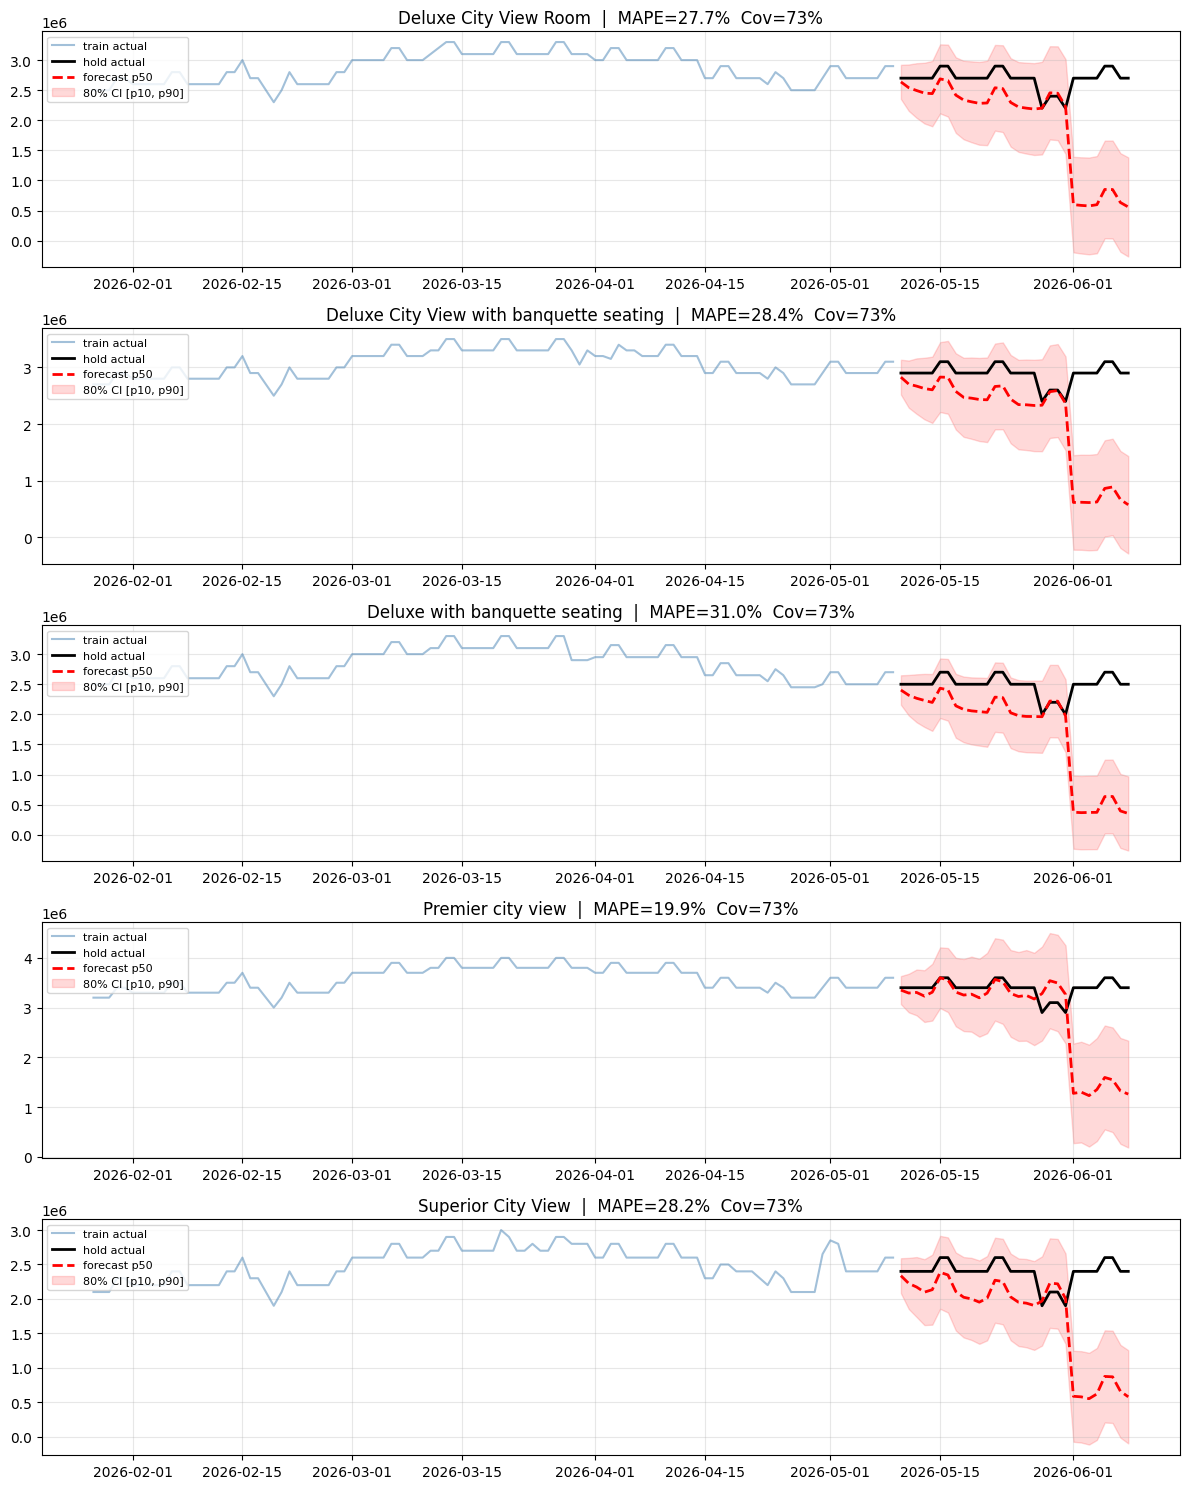

In [5]:
from src.forecast import ForecastModel, model_path

fig, axes = plt.subplots(len(room_types), 1, figsize=(12, 3 * len(room_types)), sharex=False)
if len(room_types) == 1:
    axes = [axes]

for ax, rt in zip(axes, room_types):
    target, exog = build_series(df_feat, 956, rt, target_lead_time=30, tolerance=5)
    target = target.dropna()
    train_y, hold_y = target.iloc[:-30], target.iloc[-30:]
    hold_x = exog.loc[hold_y.index]

    model = ForecastModel.load(model_path(956, rt))
    fc = model.predict(30, exog_future=hold_x, index=hold_y.index)

    ax.plot(train_y.index, train_y.values, color='steelblue', alpha=0.5, label='train actual')
    ax.plot(hold_y.index, hold_y.values, color='black', linewidth=2, label='hold actual')
    ax.plot(fc.p50.index, fc.p50.values, color='red', linewidth=2, linestyle='--', label='forecast p50')
    ax.fill_between(fc.p10.index, fc.p10.values, fc.p90.values,
                     color='red', alpha=0.15, label='80% CI [p10, p90]')

    mape = (np.abs(hold_y - fc.p50) / hold_y).mean() * 100
    cov = ((hold_y >= fc.p10) & (hold_y <= fc.p90)).mean() * 100
    ax.set_title(f'{rt}  |  MAPE={mape:.1f}%  Cov={cov:.0f}%')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 5. Sử dụng model — forecast tương lai

Demo: load 1 model đã save, predict 14 ngày tới (sau holdout). Cần build exog tương ứng cho future dates.

*(Phần này preview cho Bước 6 — Streamlit app sẽ gọi tương tự.)*

In [6]:
import holidays as holidays_pkg

model = ForecastModel.load(model_path(956, 'Superior City View'))

# Forecast 14 ngày bắt đầu sau last_train_date
n_future = 14
future_idx = pd.date_range(model.last_train_date + pd.Timedelta(days=1),
                            periods=n_future, freq='D')

# Build exog cho future (cùng schema như EXOG_COLS)
vn = set(holidays_pkg.country_holidays('VN', years=list(range(2025, 2028))).keys())
future_exog = pd.DataFrame({
    'is_holiday': pd.Series(future_idx.date).isin(vn).astype(int).values,
    'is_weekend': (future_idx.dayofweek >= 5).astype(int),
    'dow_sin': np.sin(2 * np.pi * future_idx.dayofweek / 7),
    'dow_cos': np.cos(2 * np.pi * future_idx.dayofweek / 7),
    'month_sin': np.sin(2 * np.pi * future_idx.month / 12),
    'month_cos': np.cos(2 * np.pi * future_idx.month / 12),
}, index=future_idx)

fc = model.predict(n_future, exog_future=future_exog, index=future_idx)
fc.to_frame().round(0).assign(dow=future_idx.day_name())

,p10,p50,p90,dow
2026-05-10,2081898.0,2336446.0,2590994.0,Sunday
2026-05-11,1853289.0,2224520.0,2595751.0,Monday
2026-05-12,1737049.0,2172490.0,2607930.0,Tuesday
2026-05-13,1619580.0,2098058.0,2576535.0,Wednesday
2026-05-14,1625612.0,2134027.0,2642441.0,Thursday
2026-05-15,1856112.0,2385938.0,2915764.0,Friday
2026-05-16,1802475.0,2347851.0,2893227.0,Saturday
2026-05-17,1540915.0,2107474.0,2674033.0,Sunday
2026-05-18,1440011.0,2023879.0,2607748.0,Monday
2026-05-19,1403397.0,1999726.0,2596055.0,Tuesday


## 6. Caveats + Insights cho Bước 4

### Limitations đã biết
1. **MAPE còn cao** — POC scope. Cải thiện future:
   - Log-transform price (`np.log(price)`) để stabilize variance
   - Train trên data dài hơn (>= 200 days/series)
   - Thêm exog: temperature, event calendar (concert, conference địa phương)
2. **Fixed lead_time = 30** là design choice. Khi data có thêm 3+ tháng `updated_date`, quay lại convention ROADMAP (latest snapshot) hoặc train multi-horizon (X=7, 30, 60).
3. **CI band** native từ SARIMAX dựa trên Gaussian assumption — outlier (Tết spike) có thể dao động ngoài band; coverage thực tế có thể khác 80%.

### Connection sang Bước 4 (Demand model)
- Forecast cho ta **price_grid** (đường giá tương lai). Bước 5 (pricing) sẽ explore quanh forecast: `price ∈ [p10 × 0.7, p90 × 1.3]`.
- Demand model sẽ trả `P(book | price, context)` cho mỗi giá ứng viên trong grid.
- Expected revenue = `price × P(book)` → optimal price.